In [1]:
def solution(priorities):
    sorted_priorities = sorted(priorities, reverse=True)
    return sorted_priorities
  
  
print(solution([3, 1, 5, 2, 4]))
print(solution([2, 5, 2, 4, 5]))
print(solution([7])) 


[5, 4, 3, 2, 1]
[5, 5, 4, 2, 2]
[7]


In [1]:


import heapq
##heapq 는 heap 여러값을 넣고, 뽑을때 가장 적은 값을 뽑아준다는 특성

##힙에 넣을때 그냥 안넣고 -붙여서 넣어주고, 뽑을때 다시 -(마이너스)붙여서 
heap = []

priorities = []

for priority in priorities:
    heapq.heappush(heap, priority) ## 만약 heap, -priority로 대체하면 출력이 반대로 나옴


result = []

while heap:
    priority = heapq.heappop(heap)
    result.append(priority)


print(result)




[]


In [6]:
import pandas as pd

# 시트 2개를 모두 읽어서 합치기
sheets = pd.read_excel(
    r'C:\Users\usm95\TIL-KANT-Sparta\Daily_worksheet\이커머스 (2).xlsx',
    sheet_name=None
)
df = pd.concat(sheets.values(), ignore_index=True)
print(df.shape)   # (1067371, 8) 나와야 함

# 다음 실행부터는 이걸로 (엑셀 재읽기 1~3분 절약)
df.to_pickle('ecommerce.pkl')


# ---- 전처리 ----
df = df.drop_duplicates()
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df['Amount'] = df['Quantity'] * df['Price']
print(len(df))   # 1007913 나와야 함


# ---- 이상치 탐지 ----

# 1) Price — 도메인 기준
non_product = ['M', 'POST', 'DOT', 'B', 'AMAZONFEE',
               'C2', 'BANK CHARGES', 'S', 'D']
price_out = df[df['StockCode'].astype(str).isin(non_product)]
print('Price', len(price_out), round(len(price_out)/len(df)*100, 2))

# 2) Quantity — Z-score
z = (df['Quantity'] - df['Quantity'].mean()) / df['Quantity'].std()
qty_out = df[z.abs() >= 3]
qty_upper = df['Quantity'].mean() + 3 * df['Quantity'].std()
print('Quantity', len(qty_out), round(len(qty_out)/len(df)*100, 2), round(qty_upper, 1))

# 3) Amount — Z-score
z = (df['Amount'] - df['Amount'].mean()) / df['Amount'].std()
amt_out = df[z.abs() >= 3]
amt_upper = df['Amount'].mean() + 3 * df['Amount'].std()
print('Amount', len(amt_out), round(len(amt_out)/len(df)*100, 2), round(amt_upper, 1))

(1067371, 8)
1007913
Price 4425 0.44
Quantity 1553 0.15 396.5
Amount 1537 0.15 637.5


In [ ]:
p

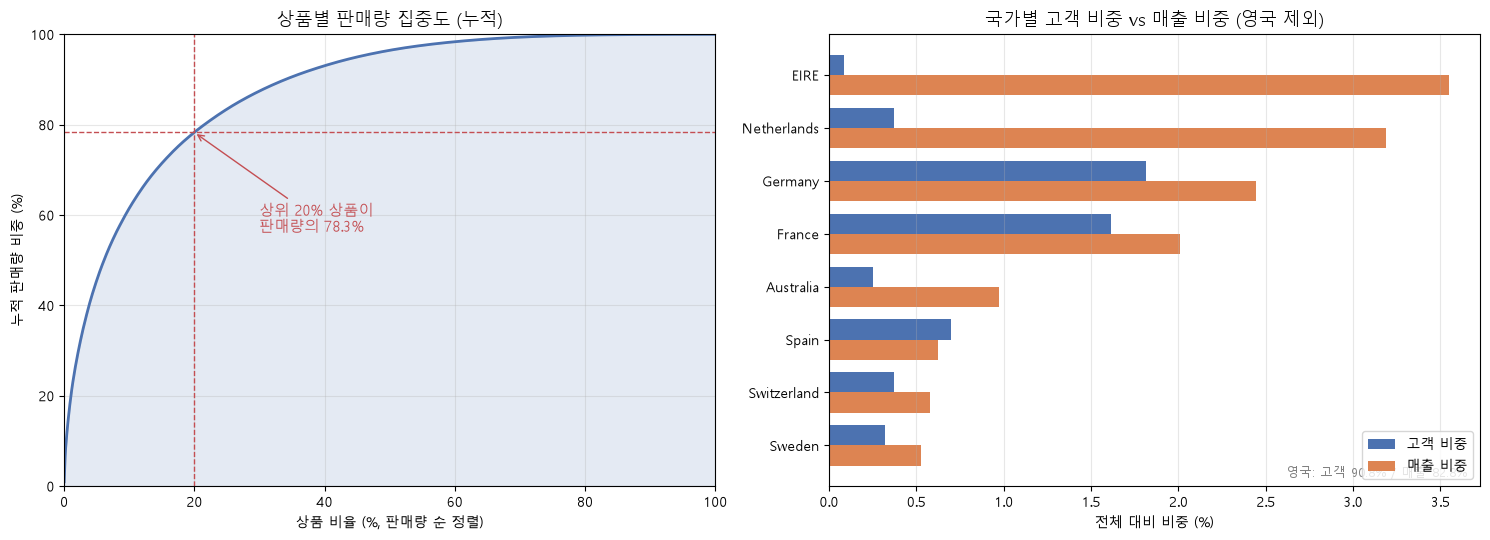

상위 10개 상품 누적 비중: 7.6%
상위 100개 상품 누적 비중: 28.8%
상위 20% 상품 누적 비중: 78.3%
상위 50% 상품 누적 비중: 96.5%
                 고객수       고객비중       매출비중     고객당매출
Country                                             
United Kingdom  5350  90.816500  82.816673    2690.0
EIRE               5   0.084875   3.548647  123314.0
Netherlands       22   0.373451   3.188744   25184.0
Germany          107   1.816330   2.446184    3972.0
France            95   1.612629   2.007326    3671.0
Australia         15   0.254626   0.974304   11286.0
Spain             41   0.695977   0.623503    2642.0
Switzerland       22   0.373451   0.575903    4548.0


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# ---------- 데이터 준비 ----------
sheets = pd.read_excel(
    r'C:\Users\usm95\TIL-KANT-Sparta\Daily_worksheet\이커머스 (2).xlsx',
    sheet_name=None
)
df = pd.concat(sheets.values(), ignore_index=True)

df = df.drop_duplicates()
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df['Amount'] = df['Quantity'] * df['Price']

non_product = ['M', 'POST', 'DOT', 'B', 'AMAZONFEE',
               'C2', 'BANK CHARGES', 'S', 'D']
prod = df[~df['StockCode'].astype(str).isin(non_product)]


fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ---------- 좌: 상품 판매량 파레토 ----------
qty = prod.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False)
cum = qty.cumsum() / qty.sum() * 100
x = np.arange(1, len(qty) + 1) / len(qty) * 100   # 상품 비율(%)

ax = axes[0]
ax.plot(x, cum.values, color='#4C72B0', linewidth=2)
ax.fill_between(x, cum.values, alpha=0.15, color='#4C72B0')

# 상위 20% 지점 표시
i20 = int(len(qty) * 0.2) - 1
ax.axvline(20, color='#C44E52', linestyle='--', linewidth=1)
ax.axhline(cum.iloc[i20], color='#C44E52', linestyle='--', linewidth=1)
ax.annotate(f'상위 20% 상품이\n판매량의 {cum.iloc[i20]:.1f}%',
            xy=(20, cum.iloc[i20]), xytext=(30, cum.iloc[i20] - 22),
            fontsize=11, color='#C44E52',
            arrowprops=dict(arrowstyle='->', color='#C44E52'))

ax.set_title('상품별 판매량 집중도 (누적)', fontsize=13)
ax.set_xlabel('상품 비율 (%, 판매량 순 정렬)')
ax.set_ylabel('누적 판매량 비중 (%)')
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.grid(alpha=0.3)


# ---------- 우: 국가별 고객 비중 vs 매출 비중 ----------
cust = df[df['Customer ID'].notna()]
g = cust.groupby('Country').agg(
    고객수=('Customer ID', 'nunique'),
    매출=('Amount', 'sum')
)
g['고객비중'] = g['고객수'] / g['고객수'].sum() * 100
g['매출비중'] = g['매출'] / g['매출'].sum() * 100

top = g.drop('United Kingdom').nlargest(8, '매출')[::-1]
y = np.arange(len(top))
h = 0.38

ax = axes[1]
ax.barh(y + h/2, top['고객비중'], height=h, label='고객 비중', color='#4C72B0')
ax.barh(y - h/2, top['매출비중'], height=h, label='매출 비중', color='#DD8452')
ax.set_yticks(y); ax.set_yticklabels(top.index)
ax.set_title('국가별 고객 비중 vs 매출 비중 (영국 제외)', fontsize=13)
ax.set_xlabel('전체 대비 비중 (%)')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

uk = g.loc['United Kingdom']
ax.text(0.98, 0.02,
        f"영국: 고객 {uk['고객비중']:.1f}% / 매출 {uk['매출비중']:.1f}%",
        transform=ax.transAxes, ha='right', fontsize=9, color='gray')

plt.tight_layout()
plt.show()


# ---------- 해석용 수치 출력 ----------
for k in [10, 100]:
    print(f'상위 {k}개 상품 누적 비중: {cum.iloc[k-1]:.1f}%')
for pct in [0.2, 0.5]:
    i = int(len(qty) * pct) - 1
    print(f'상위 {pct*100:.0f}% 상품 누적 비중: {cum.iloc[i]:.1f}%')

g['고객당매출'] = (g['매출'] / g['고객수']).round(0)
print(g.nlargest(8, '매출')[['고객수', '고객비중', '매출비중', '고객당매출']])

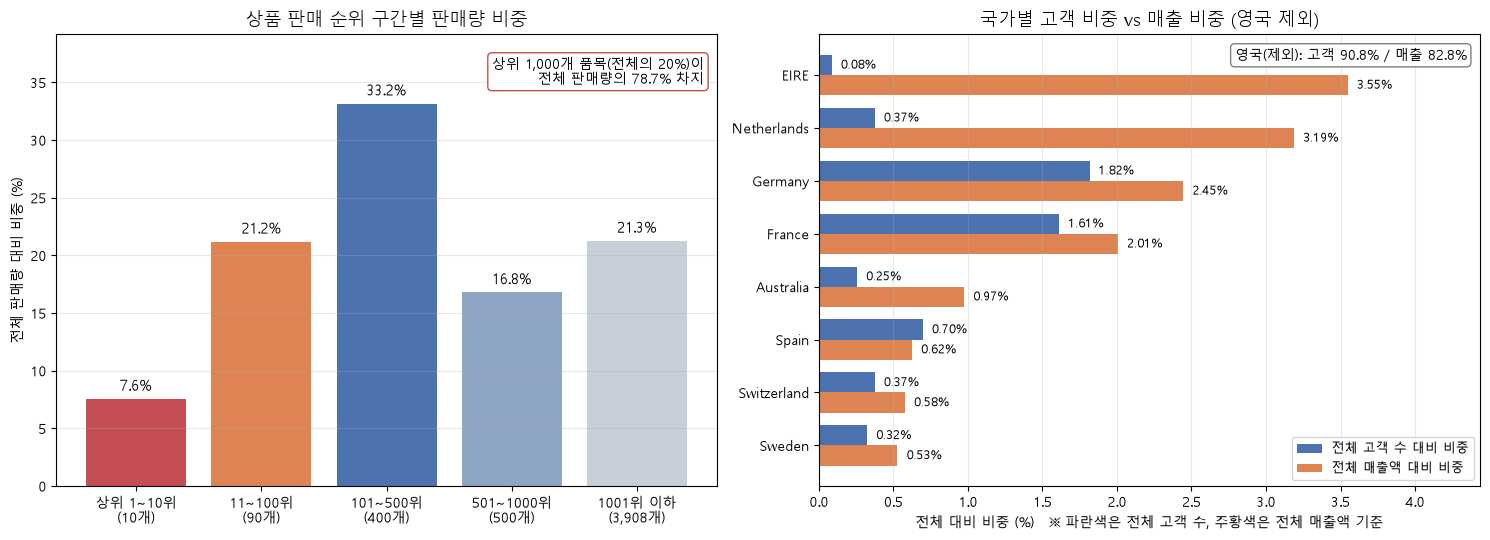

                 고객수   고객비중   매출비중     고객당매출
Country                                     
United Kingdom  5350  90.82  82.82    2690.0
EIRE               5   0.08   3.55  123314.0
Netherlands       22   0.37   3.19   25184.0
Germany          107   1.82   2.45    3972.0
France            95   1.61   2.01    3671.0
Australia         15   0.25   0.97   11286.0
Spain             41   0.70   0.62    2642.0
Switzerland       22   0.37   0.58    4548.0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# ---------- 데이터 준비 ----------
sheets = pd.read_excel(
    r'C:\Users\usm95\TIL-KANT-Sparta\Daily_worksheet\이커머스 (2).xlsx',
    sheet_name=None
)
df = pd.concat(sheets.values(), ignore_index=True)

df = df.drop_duplicates()
df = df[~df['Invoice'].astype(str).str.startswith('C')]
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df['Amount'] = df['Quantity'] * df['Price']

non_product = ['M', 'POST', 'DOT', 'B', 'AMAZONFEE',
               'C2', 'BANK CHARGES', 'S', 'D']
prod = df[~df['StockCode'].astype(str).isin(non_product)]


fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ---------- 좌: 상품 순위 구간별 판매량 비중 ----------
qty = prod.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False)
total = qty.sum()
n = len(qty)

bins = [(0, 10, '상위 1~10위\n(10개)'),
        (10, 100, '11~100위\n(90개)'),
        (100, 500, '101~500위\n(400개)'),
        (500, 1000, '501~1000위\n(500개)'),
        (1000, n, f'1001위 이하\n({n-1000:,}개)')]

labels = [b[2] for b in bins]
shares = [qty.iloc[a:b].sum() / total * 100 for a, b, _ in bins]

ax = axes[0]
colors = ['#C44E52', '#DD8452', '#4C72B0', '#8FA5C4', '#C8CFD8']
bars = ax.bar(labels, shares, color=colors)
for bar, v in zip(bars, shares):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.7,
            f'{v:.1f}%', ha='center', fontsize=11)

ax.set_title('상품 판매 순위 구간별 판매량 비중', fontsize=13)
ax.set_ylabel('전체 판매량 대비 비중 (%)')
ax.set_ylim(0, max(shares) + 6)
ax.grid(axis='y', alpha=0.3)
ax.text(0.98, 0.95,
        f'상위 1,000개 품목(전체의 20%)이\n전체 판매량의 {sum(shares[:4]):.1f}% 차지',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='#C44E52'))


# ---------- 우: 국가별 고객 비중 vs 매출 비중 ----------
cust = df[df['Customer ID'].notna()]
g = cust.groupby('Country').agg(
    고객수=('Customer ID', 'nunique'),
    매출=('Amount', 'sum')
)
g['고객비중'] = g['고객수'] / g['고객수'].sum() * 100
g['매출비중'] = g['매출'] / g['매출'].sum() * 100

top = g.drop('United Kingdom').nlargest(8, '매출')[::-1]
y = np.arange(len(top))
h = 0.38

ax = axes[1]
b1 = ax.barh(y + h/2, top['고객비중'], height=h,
             label='전체 고객 수 대비 비중', color='#4C72B0')
b2 = ax.barh(y - h/2, top['매출비중'], height=h,
             label='전체 매출액 대비 비중', color='#DD8452')

for bars in (b1, b2):
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.06, bar.get_y() + bar.get_height()/2,
                f'{w:.2f}%', va='center', fontsize=9)

ax.set_yticks(y); ax.set_yticklabels(top.index)
ax.set_title('국가별 고객 비중 vs 매출 비중 (영국 제외)', fontsize=13)
ax.set_xlabel('전체 대비 비중 (%)   ※ 파란색은 전체 고객 수, 주황색은 전체 매출액 기준')
ax.set_xlim(0, top[['고객비중', '매출비중']].values.max() * 1.25)
ax.grid(axis='x', alpha=0.3)

uk = g.loc['United Kingdom']
ax.text(0.98, 0.97,
        f"영국(제외): 고객 {uk['고객비중']:.1f}% / 매출 {uk['매출비중']:.1f}%",
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray'))
ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()


# ---------- 해석용 수치 ----------
g['고객당매출'] = (g['매출'] / g['고객수']).round(0)
print(g.nlargest(8, '매출')[['고객수', '고객비중', '매출비중', '고객당매출']].round(2))

분석 대상 행 수: 1001940


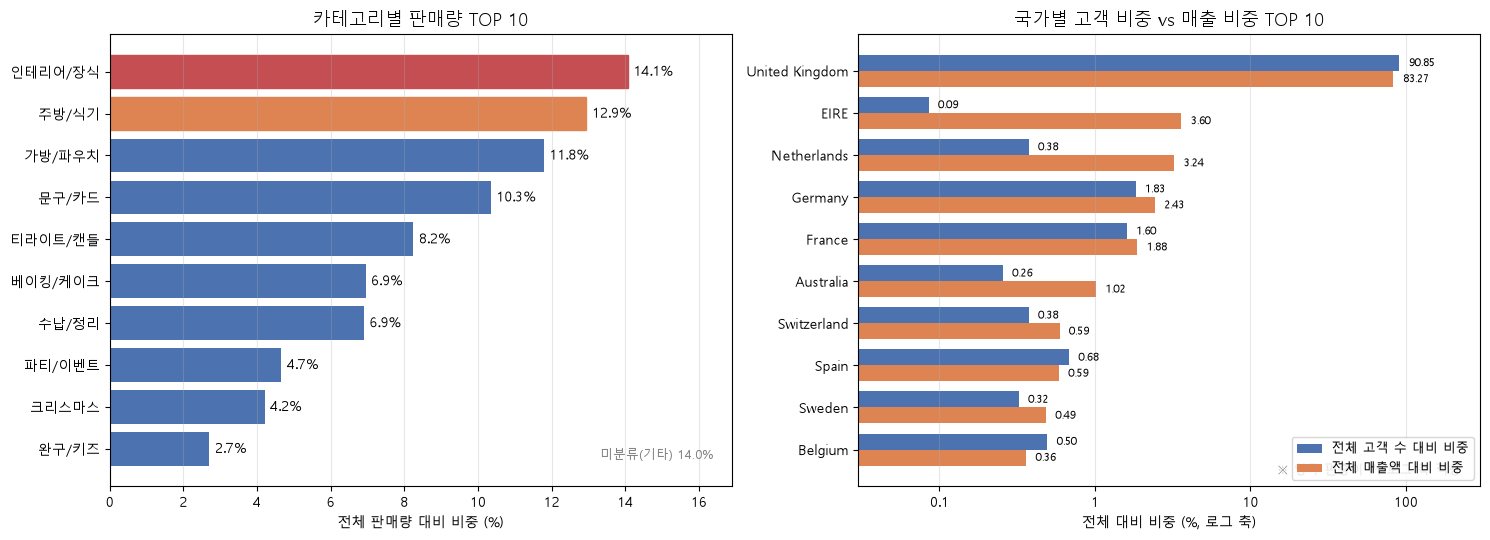

              판매량   상품수
Category               
인테리어/장식   1343758   707
기타        1338707  1114
주방/식기     1236089   754
가방/파우치    1125635   242
문구/카드      987998   374
티라이트/캔들    787495   445
베이킹/케이크    663320   170
수납/정리      659217   278
파티/이벤트     445265   153
크리스마스      401633   178
완구/키즈      258590    94
정원/야외      252475   247
욕실/뷰티       47458   226
                 고객수   고객비중   매출비중     고객당매출
Country                                     
United Kingdom  5322  90.85  83.27    2464.0
EIRE               5   0.09   3.60  113225.0
Netherlands       22   0.38   3.24   23161.0
Germany          107   1.83   2.43    3571.0
France            94   1.60   1.88    3143.0
Australia         15   0.26   1.02   10682.0
Switzerland       22   0.38   0.59    4245.0
Spain             40   0.68   0.59    2313.0
Sweden            19   0.32   0.49    4023.0
Belgium           29   0.50   0.36    1965.0


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# ---------- 데이터 준비 (이상치 제거 기준) ----------
sheets = pd.read_excel(
    r'C:\Users\usm95\TIL-KANT-Sparta\Daily_worksheet\이커머스 (2).xlsx',
    sheet_name=None
)
df = pd.concat(sheets.values(), ignore_index=True)

df = df.drop_duplicates()                                          # 완전 중복 제거
df = df[~df['Invoice'].astype(str).str.startswith('C')]            # 취소 거래 제외
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]                  # 음수·0단가 제외

non_product = ['M', 'POST', 'DOT', 'B', 'AMAZONFEE',
               'C2', 'BANK CHARGES', 'S', 'D']
df = df[~df['StockCode'].astype(str).isin(non_product)]            # 비상품 코드 제외

z = (df['Quantity'] - df['Quantity'].mean()) / df['Quantity'].std()
df = df[z.abs() < 3].copy()                                        # Quantity 이상치 제외

df['Amount'] = df['Quantity'] * df['Price']
print('분석 대상 행 수:', len(df))    # 1,001,940


# ---------- 카테고리 부여 ----------
rules = [
    ('가방/파우치',   ['BAG','SHOPPER','PURSE','POUCH','SATCHEL','TOTE']),
    ('티라이트/캔들', ['T-LIGHT','TLIGHT','CANDLE','TEALIGHT','LANTERN']),
    ('베이킹/케이크', ['CAKE','BAKING','CUPCAKE','MUFFIN','APRON','MOULD','ROLLING PIN','CAKESTAND']),
    ('파티/이벤트',   ['PARTY','BUNTING','BALLOON','NAPKIN','PAPER CHAIN','GARLAND','CONFETTI','PLACEMAT']),
    ('크리스마스',    ['CHRISTMAS','XMAS','ADVENT','SANTA','REINDEER']),
    ('주방/식기',     ['MUG','TEA','CUP','PLATE','BOWL','JUG','TRAY','CUTLERY','JAR','BOTTLE','TIN','SPOON','GLASS']),
    ('수납/정리',     ['STORAGE','BOX','BASKET','DRAWER','HOLDER','RACK','CADDY','ORGANISER']),
    ('문구/카드',     ['CARD','NOTEBOOK','PEN','PENCIL','WRAP','GIFT','STICKER','CHALK','PAPER']),
    ('완구/키즈',     ['KIDS','CHILD','TOY','DOLL','GAME','PLAYHOUSE','CRAYON','GLIDER','PAINT SET','SNAP CARDS']),
    ('인테리어/장식', ['ORNAMENT','FRAME','SIGN','CLOCK','MIRROR','CUSHION','HEART','DECORATION','HANGING','LIGHT','WREATH']),
    ('정원/야외',     ['GARDEN','PLANT','WATERING','BIRD','FLOWER','PARASOL','DOORMAT']),
    ('욕실/뷰티',     ['SOAP','BATH','TOWEL','JEWELLERY','NECKLACE','BRACELET','EARRING','HAIR']),
]

desc = df['Description'].fillna('').str.upper()
cat = pd.Series('기타', index=df.index)
for name, kws in reversed(rules):          # 앞쪽 규칙이 우선 적용되도록 역순 처리
    cat[desc.str.contains('|'.join(kws), regex=True, na=False)] = name
df['Category'] = cat


fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# ---------- 좌: 카테고리별 판매량 TOP 10 ----------
g = df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)
g = g.drop('기타', errors='ignore')                 # 미분류는 순위에서 제외
share = g / df['Quantity'].sum() * 100
top10 = share.head(10)[::-1]

ax = axes[0]
bars = ax.barh(top10.index, top10.values, color='#4C72B0')
bars[-1].set_color('#C44E52'); bars[-2].set_color('#DD8452')
for bar, v in zip(bars, top10.values):
    ax.text(v + 0.15, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=10)

ax.set_title('카테고리별 판매량 TOP 10', fontsize=13)
ax.set_xlabel('전체 판매량 대비 비중 (%)')
ax.set_xlim(0, top10.max() * 1.2)
ax.grid(axis='x', alpha=0.3)
ax.text(0.97, 0.06, f'미분류(기타) {100 - share.sum():.1f}%',
        transform=ax.transAxes, ha='right', fontsize=9, color='gray')


# ---------- 우: 국가별 고객 비중 vs 매출 비중 TOP 10 (영국 포함) ----------
cust = df[df['Customer ID'].notna()]
c = cust.groupby('Country').agg(
    고객수=('Customer ID', 'nunique'),
    매출=('Amount', 'sum')
)
c['고객비중'] = c['고객수'] / c['고객수'].sum() * 100
c['매출비중'] = c['매출'] / c['매출'].sum() * 100

top = c.nlargest(10, '매출')[::-1]
y = np.arange(len(top)); h = 0.38

ax = axes[1]
b1 = ax.barh(y + h/2, top['고객비중'], height=h,
             label='전체 고객 수 대비 비중', color='#4C72B0')
b2 = ax.barh(y - h/2, top['매출비중'], height=h,
             label='전체 매출액 대비 비중', color='#DD8452')

ax.set_xscale('log')
ax.xaxis.set_major_locator(FixedLocator([0.1, 1, 10, 100]))
ax.xaxis.set_major_formatter(FixedFormatter(['0.1', '1', '10', '100']))
ax.xaxis.set_minor_locator(FixedLocator([]))




for bars in (b1, b2):
    for bar in bars:
        w = bar.get_width()
        ax.text(w * 1.15, bar.get_y() + bar.get_height()/2,
                f'{w:.2f}', va='center', fontsize=8)

ax.set_yticks(y); ax.set_yticklabels(top.index)
ax.set_title('국가별 고객 비중 vs 매출 비중 TOP 10', fontsize=13)
ax.set_xlabel('전체 대비 비중 (%, 로그 축)')
ax.set_xlim(0.03, 300)
ax.grid(axis='x', alpha=0.3)
ax.legend(loc='lower right', fontsize=9)

ax.text(0.97, 0.02, '※ 영국 편중이 커 로그 축 적용',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=9, color='gray')

plt.tight_layout()
plt.show()


# ---------- 해석용 수치 ----------
print(df.groupby('Category').agg(
    판매량=('Quantity', 'sum'), 상품수=('StockCode', 'nunique')
).sort_values('판매량', ascending=False))

c['고객당매출'] = (c['매출'] / c['고객수']).round(0)
print(c.nlargest(10, '매출')[['고객수', '고객비중', '매출비중', '고객당매출']].round(2))

In [8]:
country_tbl = pd.pivot_table(
    df[df['Customer ID'].notna()],
    index='Country',
    values=['Customer ID', 'Invoice', 'Amount'],
    aggfunc={'Customer ID': 'nunique',
             'Invoice': 'nunique',
             'Amount': 'sum'}
).rename(columns={'Customer ID': '고객수',
                  'Invoice': '주문건수',
                  'Amount': '매출'})

country_tbl['고객비중(%)'] = (country_tbl['고객수'] / country_tbl['고객수'].sum() * 100).round(2)
country_tbl['매출비중(%)'] = (country_tbl['매출'] / country_tbl['매출'].sum() * 100).round(2)
country_tbl['고객당매출']  = (country_tbl['매출'] / country_tbl['고객수']).round(0)
country_tbl['주문당매출']  = (country_tbl['매출'] / country_tbl['주문건수']).round(0)
country_tbl['매출'] = country_tbl['매출'].round(0)

country_tbl = country_tbl[['고객수', '주문건수', '매출',
                           '고객비중(%)', '매출비중(%)',
                           '고객당매출', '주문당매출']]
country_tbl = country_tbl.sort_values('매출', ascending=False)

print(country_tbl.head(10).to_string())

from IPython.display import display
display(country_tbl.head(10))

                 고객수   주문건수          매출  고객비중(%)  매출비중(%)     고객당매출   주문당매출
Country                                                                    
United Kingdom  5322  33120  13111928.0    90.85    83.27    2464.0   396.0
EIRE               5    539    566123.0     0.09     3.60  113225.0  1050.0
Netherlands       22    211    509540.0     0.38     3.24   23161.0  2415.0
Germany          107    756    382086.0     1.83     2.43    3571.0   505.0
France            94    590    295438.0     1.60     1.88    3143.0   501.0
Australia         15     89    160227.0     0.26     1.02   10682.0  1800.0
Switzerland       22     82     93401.0     0.38     0.59    4245.0  1139.0
Spain             40    146     92537.0     0.68     0.59    2313.0   634.0
Sweden            19     98     76435.0     0.32     0.49    4023.0   780.0
Belgium           29    143     56993.0     0.50     0.36    1965.0   399.0


,고객수,주문건수,매출,고객비중(%),매출비중(%),고객당매출,주문당매출
Country,,,,,,,
United Kingdom,5322,33120,13111928.0,90.85,83.27,2464.0,396.0
EIRE,5,539,566123.0,0.09,3.60,113225.0,1050.0
Netherlands,22,211,509540.0,0.38,3.24,23161.0,2415.0
Germany,107,756,382086.0,1.83,2.43,3571.0,505.0
France,94,590,295438.0,1.60,1.88,3143.0,501.0
Australia,15,89,160227.0,0.26,1.02,10682.0,1800.0
Switzerland,22,82,93401.0,0.38,0.59,4245.0,1139.0
Spain,40,146,92537.0,0.68,0.59,2313.0,634.0
Sweden,19,98,76435.0,0.32,0.49,4023.0,780.0
